# Optimización para portafolios de inversion

In [1]:
from qiskit.circuit.library import TwoLocal
from qiskit.result import QuasiDistribution
from qiskit_aer.primitives import Sampler
from qiskit_algorithms import NumPyMinimumEigensolver, QAOA, SamplingVQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit_finance.applications.optimization import PortfolioOptimization
from qiskit_finance.data_providers import YahooDataProvider
from qiskit_optimization.algorithms import MinimumEigenOptimizer
from qiskit_finance.exceptions import QiskitFinanceError
import numpy as np
import matplotlib.pyplot as plt
import datetime

### Obtención de datos

[*********************100%***********************]  9 of 9 completed


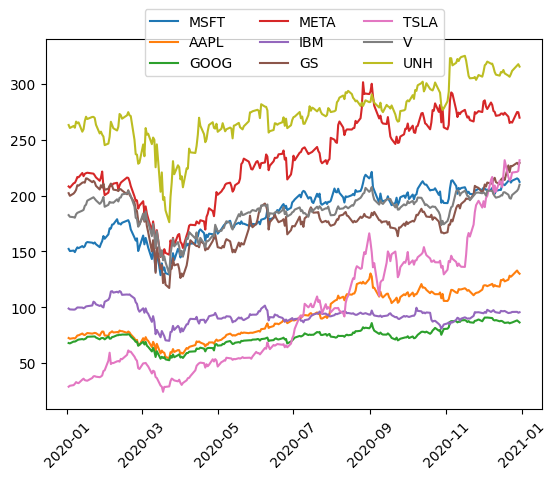

In [2]:
import datetime
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

tickers = ["MSFT", "AAPL", "GOOG", "META", "IBM", "GS", "TSLA", "V", "UNH"]

raw = yf.download(
    tickers,
    start="2020-01-01",
    end="2020-12-31",
    auto_adjust=False
)

prices = raw["Adj Close"]

for ticker in tickers:
    plt.plot(prices[ticker], label=ticker)

plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.1), ncol=3)
plt.xticks(rotation=45)
plt.show()

In [5]:
returns = prices.pct_change().dropna()

mu = returns.mean().to_numpy()

sigma = returns.cov().to_numpy()

print("Vector de rendimientos esperados:")
print(mu)
#print(sigma)

Vector de rendimientos esperados:
[0.00276907 0.00125223 0.00104221 0.00019794 0.00145424 0.00171069
 0.0099507  0.0011853  0.00091724]


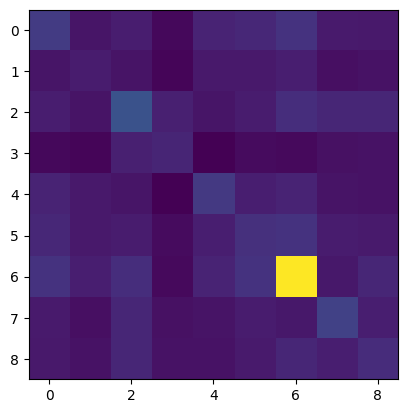

In [6]:
# plot sigma
plt.imshow(sigma, interpolation="nearest")
plt.show()

[*********************100%***********************]  3 of 3 completed


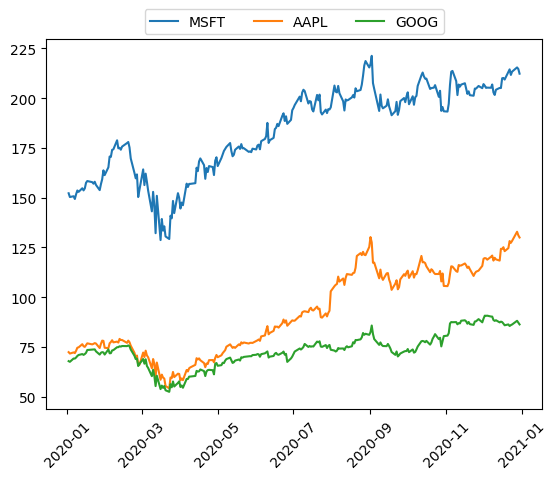

In [7]:
import datetime
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

tickers = ["MSFT", "AAPL", "GOOG"]
raw = yf.download(
    tickers,
    start="2020-01-01",
    end="2020-12-31",
    auto_adjust=False
)

prices = raw["Adj Close"]

for ticker in tickers:
    plt.plot(prices[ticker], label=ticker)

plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.1), ncol=3)
plt.xticks(rotation=45)
plt.show()

In [10]:
returns = prices.pct_change().dropna()

mu = returns.mean().to_numpy()

sigma = returns.cov().to_numpy()

print("Vector de rendimientos esperados:")
print(mu)
#print(sigma)

Vector de rendimientos esperados:
[0.00276907 0.00125223 0.00171069]


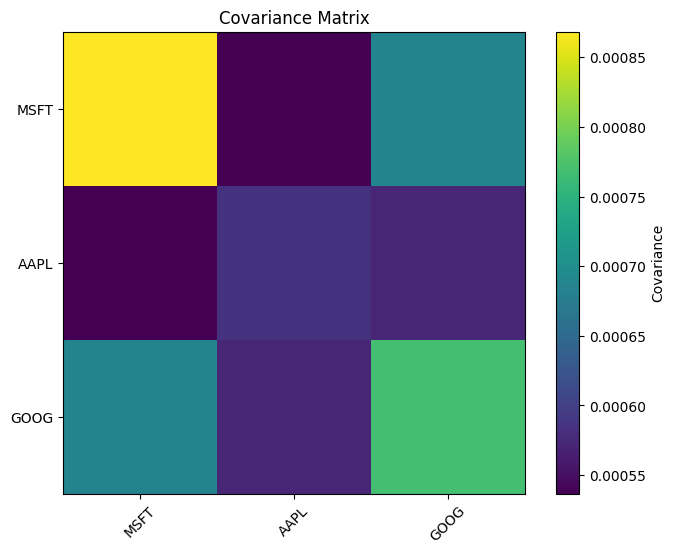

In [13]:
plt.figure(figsize=(8, 6))
plt.imshow(sigma, interpolation="nearest")
plt.colorbar(label="Covariance")

plt.xticks(range(len(tickers)), tickers, rotation=45)
plt.yticks(range(len(tickers)), tickers)

plt.title("Covariance Matrix")
plt.show()

In [14]:

portfolio = PortfolioOptimization(
    expected_returns=mu,
    covariances=sigma,
    risk_factor=0.5,
    budget=2
)

# Convert to quadratic program (QUBO)
qp = portfolio.to_quadratic_program()

# Print optimization problem
print(qp.prettyprint())

Problem name: Portfolio optimization

Minimize
  0.00043421602692741263*x_0^2 + 0.000536570787457193*x_0*x_1
  + 0.0006861880818213197*x_0*x_2 + 0.0002927133443756887*x_1^2
  + 0.0005720632829401376*x_1*x_2 + 0.00038459517365487954*x_2^2
  - 0.0027690701833245654*x_0 - 0.0012522308968900197*x_1
  - 0.001710687634099605*x_2

Subject to
  Linear constraints (1)
    x_0 + x_1 + x_2 == 2  'c0'

  Binary variables (3)
    x_0 x_1 x_2

